In [1]:
import numpy as np
import cv2
import dlib
import matplotlib.pyplot as plt
from IPython.display import clear_output, display
print('all assets imported!')

all assets imported!


In [2]:
# Video capture to read frames from webcam
captured_culprit = cv2.VideoCapture(0)

# Use OpenCV Haar cascade face detector (more robust in this environment)
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
 )

if face_cascade.empty():
    raise RuntimeError('Failed to load Haar cascade for face detection.')

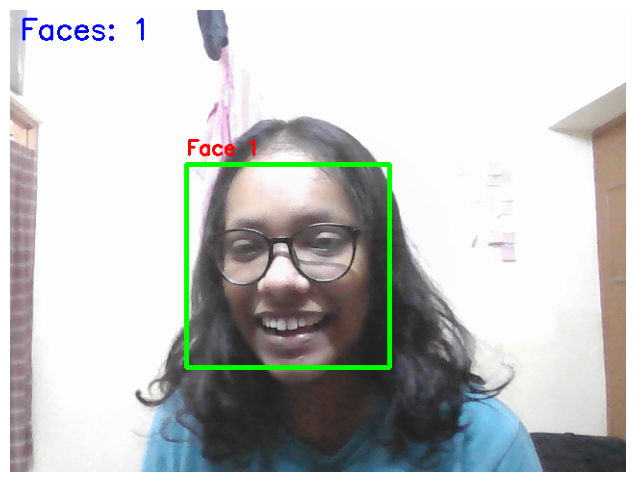

In [3]:
frame_count = 0
max_frames = 300  # safety stop so notebook execution ends automatically

plt.figure(figsize=(8, 6))

while True:
    # Capture frame-by-frame
    ret, frame = captured_culprit.read()
    if not ret or frame is None:
        break

    frame = cv2.flip(frame, 1)

    # Convert to grayscale for Haar cascade detector
    gray_img = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(
        gray_img,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(30, 30)
    )

    # Draw detections and face count
    i = 0
    for (x, y, w, h) in faces:
        x1, y1 = x + w, y + h
        cv2.rectangle(frame, (x, y), (x1, y1), (0, 255, 0), 3)
        i += 1
        cv2.putText(
            frame,
            'Face ' + str(i),
            (x, y - 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (0, 0, 255),
            2
        )

    cv2.putText(
        frame,
        'Faces: ' + str(i),
        (10, 30),
        cv2.FONT_HERSHEY_SIMPLEX,
        1.0,
        (255, 0, 0),
        2
    )

    # Show live frame inline in notebook
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    clear_output(wait=True)
    plt.imshow(frame_rgb)
    plt.axis('off')
    display(plt.gcf())
    plt.clf()

    frame_count += 1
    if frame_count >= max_frames:
        break

captured_culprit.release()
cv2.destroyAllWindows()
clear_output(wait=True)
plt.close()